# 05 – Proportional Control

**Manufacturing context:** A position controller on a CNC axis. Open-loop commands give unpredictable results; closing the loop with feedback and a proportional gain `Kp` dramatically improves tracking.

**Control law:** &ensp; `u = Kp * (ref - y)`  
**Key tradeoff:** Higher `Kp` = faster response but more overshoot.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Editable parameters ----
# Plant (second-order mass-spring-damper)
m = 1.0      # Mass [kg]
c = 1.0      # Damping [N*s/m]
k = 4.0      # Stiffness [N/m]
ref = 1.0    # Desired position setpoint [m]
t_end = 8.0
dt = 0.001

# Proportional gains to compare
Kp_values = [5.0, 20.0,60 80.0]
# -----------------------------

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3403586666.py, line 14)

In [2]:
t = np.arange(0, t_end, dt)

def simulate_p_control(Kp):
    """Closed-loop proportional control: u = Kp * error."""
    x = np.zeros_like(t)
    v = np.zeros_like(t)
    u = np.zeros_like(t)
    for i in range(1, len(t)):
        e = ref - x[i-1]
        u[i] = Kp * e
        a = (u[i] - c * v[i-1] - k * x[i-1]) / m
        v[i] = v[i-1] + a * dt
        x[i] = x[i-1] + v[i] * dt
    return x, u

def compute_step_metrics(x, ref, t):
    """Return overshoot and 10-90% rise time for a response curve."""
    peak = np.max(x)
    overshoot = max(0.0, (peak - ref) / ref * 100.0)

    low_threshold = 0.1 * ref
    high_threshold = 0.9 * ref

    crossed_low = np.where(x >= low_threshold)[0]
    crossed_high = np.where(x >= high_threshold)[0]

    rise_time = np.nan
    if crossed_low.size and crossed_high.size:
        t_low = t[crossed_low[0]]
        later_high = crossed_high[crossed_high >= crossed_low[0]]
        if later_high.size:
            rise_time = t[later_high[0]] - t_low

    return {
        "overshoot_pct": overshoot,
        "rise_time_s": rise_time,
    }

# Run all Kp cases
results = {}
efforts = {}
metrics = {}
for Kp in Kp_values:
    x, u = simulate_p_control(Kp)
    label = f"Kp={Kp}"
    results[label] = x
    efforts[label] = u
    metrics[label] = compute_step_metrics(x, ref, t)


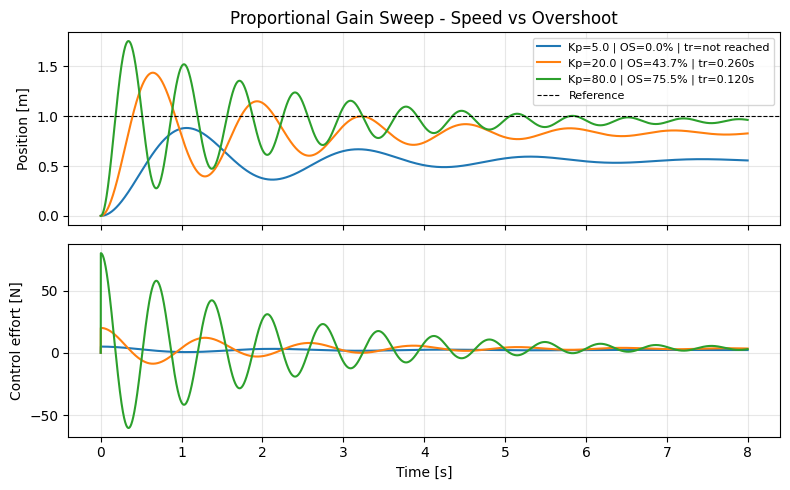

Step-response metrics (relative to the 1.0 m reference)
- Overshoot: peak amount above the reference
- Rise time: time from 10% to 90% of the reference; 'not reached' means the curve never reaches 90%
Kp=5.0   overshoot =   0.0%   rise time = not reached
Kp=20.0  overshoot =  43.7%   rise time = 0.260 s
Kp=80.0  overshoot =  75.5%   rise time = 0.120 s


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

for label, x in results.items():
    curve_metrics = metrics[label]
    rise_time = curve_metrics["rise_time_s"]
    rise_text = f"{rise_time:.3f}s" if np.isfinite(rise_time) else "not reached"
    legend_label = (
        f"{label} | OS={curve_metrics['overshoot_pct']:.1f}% | tr={rise_text}"
    )
    axes[0].plot(t, x, label=legend_label)
axes[0].axhline(ref, color="k", linestyle="--", linewidth=0.8, label="Reference")
axes[0].set_ylabel("Position [m]")
axes[0].set_title("Proportional Gain Sweep - Speed vs Overshoot")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for label, u in efforts.items():
    axes[1].plot(t, u, label=label)
axes[1].set_ylabel("Control effort [N]")
axes[1].set_xlabel("Time [s]")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print("Step-response metrics (relative to the 1.0 m reference)")
print("- Overshoot: peak amount above the reference")
print("- Rise time: time from 10% to 90% of the reference; 'not reached' means the curve never reaches 90%")
for label, curve_metrics in metrics.items():
    rise_time = curve_metrics["rise_time_s"]
    rise_text = f"{rise_time:.3f} s" if np.isfinite(rise_time) else "not reached"
    print(
        f"{label:<8} overshoot = {curve_metrics['overshoot_pct']:>5.1f}%   rise time = {rise_text}"
    )


### Student Exercise

1. Add `Kp=2.0` to the list. What happens to steady-state error?
2. Try to find a `Kp` that gives < 10% overshoot and < 0.5s rise time.
3. Why can't P-only control eliminate steady-state error on this plant?